# Neural network climatology: Air temperature observations (UK)

In this notebook, we model temperature over the UK region.
We load observations data with additional predictors (roughness, land fraction), apply suitable transformations.

Data: 

observations_qc.csv

land_fraction_data.csv

roughness_data.csv

We use additional predictors along with the intially provided covariates to potentially improve learning process of our models.

Model and libraries:

We use tensorflow and keras libraries to build neural network climatology models and evaluate them with MAE metric.
Furthermore, we create various visual plots to analyse the results.


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import norm

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text
import matplotlib.patheffects as pe

# Libraries for Neural Networks
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import layers, models
import datetime
from tensorflow.keras.callbacks import TensorBoard
import keras
print(tf.__version__)

import keras_tuner
import math

## Loading Observations and additional predictors

In [ ]:
obs = pd.read_csv('./datasets/observations_qc.csv', compression="gzip", parse_dates=["time"])
land_frac_data = pd.read_csv('./datasets/land_fraction_data.csv', compression="gzip")
roughness_data = pd.read_csv('./datasets/roughness_data.csv', compression="gzip")

obs = obs.merge(land_frac_data, how='left', on=['wmo_id','latitude','longitude', 'altitude'])
obs = obs.merge(roughness_data, how='left', on=['wmo_id','latitude','longitude', 'altitude'])

print(obs.shape)
print(obs.columns)
print((obs['ob_value']-273.15).min())
print((obs['ob_value']-273.15).max())

## UK Data Subset

In [7]:
obs_uk = obs[(obs['latitude'] > 49.8) & (obs['latitude'] < 61.5)  & (obs['longitude'] > -8.5) & (obs['longitude'] < 1.8)]
obs_uk.shape[0]

708705

In [9]:
obs = obs_uk.copy()
obs.shape

(708705, 9)

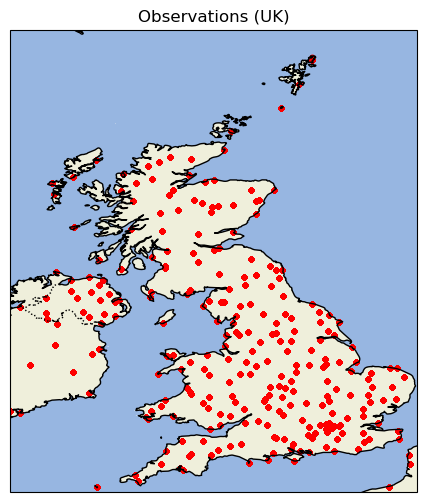

In [16]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-8.5, 1.8, 49.8, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
#ax.set_global()

# Plot points
ax.scatter(obs['longitude'], obs['latitude'], color='red', s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Observations (UK)")
plt.show()


## Data Transformations

In [10]:
# Transforming date to a cyclic pattern in a 365 day cycle
obs['day_of_year'] = obs['time'].dt.dayofyear
obs['hour'] = pd.to_datetime(obs['time']).dt.hour

#obs['sin_day'] = np.sin(2 * np.pi * (obs['day_of_year'] + obs['hour']/24) / 365).round(5)
#obs['cos_day'] = np.cos(2 * np.pi * (obs['day_of_year'] + obs['hour']/24) / 365).round(5)

obs['sin_day'] = np.sin(2 * np.pi * obs['day_of_year'] / 365).round(5)
obs['cos_day'] = np.cos(2 * np.pi * obs['day_of_year'] / 365).round(5)

# Transforming time to a cyclic pattern - 24 hour cycle by calculating the solar time at positions
obs['sin_hour'] = np.sin(2 * np.pi * (obs['hour'] + 24 * (obs['longitude'] / 360)) / 24).round(5)
obs['cos_hour'] = np.cos(2 * np.pi * (obs['hour'] + 24 * (obs['longitude'] / 360)) / 24).round(5)


In [11]:
# Transforming latitude, longitude to [-1,1] range
obs['lat'] = (obs['latitude']/90.0).round(5)
obs['sin_long'] = np.sin(np.radians(obs['longitude'])).round(5)
obs['cos_long'] = np.cos(np.radians(obs['longitude'])).round(5)

obs['temp_celsius'] = obs['ob_value'] - 273.15

In [12]:
obs.head(10)

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness,day_of_year,hour,sin_day,cos_day,sin_hour,cos_hour,lat,sin_long,cos_long,temp_celcius
3824615,281.1,2025-02-01 00:00:00+00:00,3803,temperature_at_screen_level,49.914,-6.296,36.0,0.0000,0.03,32,0,0.52342,0.85208,-0.10966,0.99397,0.5546,-0.10966,0.99397,8.1
3824616,281.1,2025-02-01 01:00:00+00:00,3803,temperature_at_screen_level,49.914,-6.296,36.0,0.0000,0.03,32,1,0.52342,0.85208,0.15133,0.98848,0.5546,-0.10966,0.99397,8.1
3824617,281.1,2025-02-01 02:00:00+00:00,3803,temperature_at_screen_level,49.914,-6.296,36.0,0.0000,0.03,32,2,0.52342,0.85208,0.40201,0.91563,0.5546,-0.10966,0.99397,8.1
3824618,281.4,2025-02-01 03:00:00+00:00,3803,temperature_at_screen_level,49.914,-6.296,36.0,0.0000,0.03,32,3,0.52342,0.85208,0.62530,0.78039,0.5546,-0.10966,0.99397,8.4
3824619,281.2,2025-02-01 04:00:00+00:00,3803,temperature_at_screen_level,49.914,-6.296,36.0,0.0000,0.03,32,4,0.52342,0.85208,0.80597,0.59196,0.5546,-0.10966,0.99397,8.2
3824620,282.0,2025-02-01 05:00:00+00:00,3803,temperature_at_screen_level,49.914,-6.296,36.0,0.0000,0.03,32,5,0.52342,0.85208,0.93172,0.36319,0.5546,-0.10966,0.99397,9.0
3824633,276.4,2025-02-01 00:00:00+00:00,7040,temperature_at_screen_level,49.932,1.089,38.0,0.1581,0.03,32,0,0.52342,0.85208,0.01901,0.99982,0.5548,0.01901,0.99982,3.4
3824634,276.4,2025-02-01 01:00:00+00:00,7040,temperature_at_screen_level,49.932,1.089,38.0,0.1581,0.03,32,1,0.52342,0.85208,0.27713,0.96083,0.5548,0.01901,0.99982,3.4
3824635,276.0,2025-02-01 02:00:00+00:00,7040,temperature_at_screen_level,49.932,1.089,38.0,0.1581,0.03,32,2,0.52342,0.85208,0.51637,0.85637,0.5548,0.01901,0.99982,3.0
3824636,275.8,2025-02-01 03:00:00+00:00,7040,temperature_at_screen_level,49.932,1.089,38.0,0.1581,0.03,32,3,0.52342,0.85208,0.72042,0.69354,0.5548,0.01901,0.99982,2.8


## Climatology: Neural Network Model using TensorFlow

### Data Preparation

In [22]:
df = obs.copy()
print(df.columns)
df.head(5)

Index(['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude',
       'altitude', 'land_fraction', 'roughness', 'day_of_year', 'hour',
       'sin_day', 'cos_day', 'sin_hour', 'cos_hour', 'lat', 'sin_long',
       'cos_long', 'temp_celcius'],
      dtype='object')

In [33]:
#Splitting dataset into train, test and validation set with a ratio of 70:15:15.
unique_wmo_ids = df['wmo_id'].unique()
unique_wmo_ids.shape
np.random.seed(0)
np.random.shuffle(unique_wmo_ids)

#Splitting data by 70-30 ratio
split_index = int(0.7 * len(unique_wmo_ids))
train_ids = unique_wmo_ids[:split_index]

split_index_1 = int(0.5 * (len(unique_wmo_ids) - len(train_ids)))
val_ids = unique_wmo_ids[split_index : (split_index + split_index_1)]
test_ids = unique_wmo_ids[(split_index + split_index_1):]

df_train = df[df['wmo_id'].isin(train_ids)]
df_val = df[df['wmo_id'].isin(val_ids)]
df_test = df[df['wmo_id'].isin(test_ids)]

print(train_ids.shape)
print(val_ids.shape)
print(test_ids.shape)
print(df_train.shape)
print(df_val.shape)
print(df_test.shape)


### Visualising train, test, val sites and storing data for visualisations

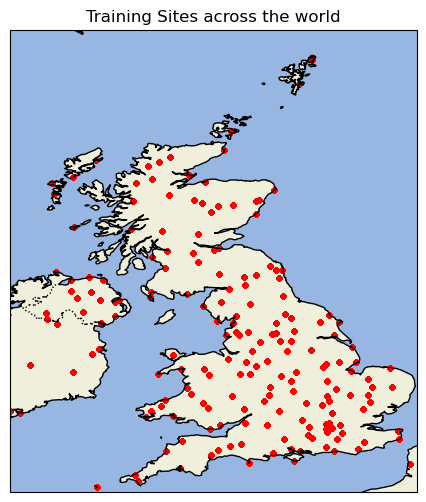

In [115]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-8.5, 1.8, 49.8, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
#ax.set_global()

# Plot points
ax.scatter(df_train['longitude'], df_train['latitude'], color='red', s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Training Sites")
plt.show()

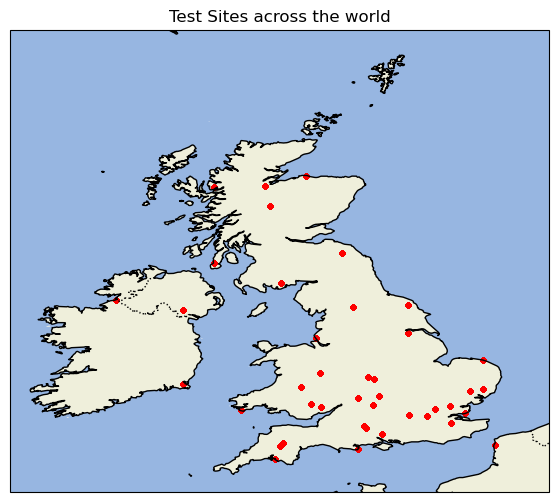

In [119]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
#ax.set_global()

# Plot points
ax.scatter(df_test['longitude'], df_test['latitude'], color='red', s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Test Sites")
plt.show()

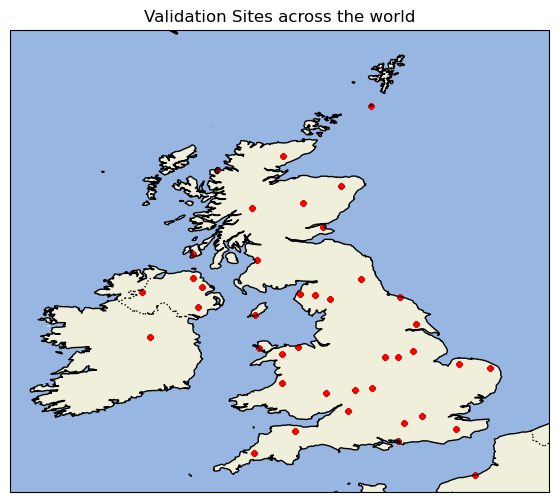

In [123]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
#ax.set_global()

# Plot points
ax.scatter(df_val['longitude'], df_val['latitude'], color='red', s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Validation Sites")
plt.show()

In [39]:
map_values = df_test[['latitude', 'longitude','altitude', 'temp_celsius', 'day_of_year']]
map_values

,latitude,longitude,altitude,temp_celcius,day_of_year
6030894,51.555,0.827,2.0,4.2,32
6030895,51.555,0.827,2.0,4.8,32
6030896,51.555,0.827,2.0,4.7,32
6030897,51.555,0.827,2.0,4.6,32
6030898,51.555,0.827,2.0,4.6,32
...,...,...,...,...,...
8147103,57.418,-5.689,773.0,11.2,140
8147104,57.418,-5.689,773.0,12.5,140
8147105,57.418,-5.689,773.0,11.1,140
8147106,57.418,-5.689,773.0,10.5,140


### Training Data

In [43]:
df_train = df_train.drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])
df_val = df_val.drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])
df_test = df_test.drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])

df_test

,altitude,land_fraction,roughness,sin_day,cos_day,sin_hour,cos_hour,lat,sin_long,cos_long,temp_celcius
6030894,2.0,0.988718,0.03,0.52342,0.85208,0.01443,0.99990,0.57283,0.01443,0.99990,4.2
6030895,2.0,0.988718,0.03,0.52342,0.85208,0.27273,0.96209,0.57283,0.01443,0.99990,4.8
6030896,2.0,0.988718,0.03,0.52342,0.85208,0.51245,0.85872,0.57283,0.01443,0.99990,4.7
6030897,2.0,0.988718,0.03,0.52342,0.85208,0.71724,0.69683,0.57283,0.01443,0.99990,4.6
6030898,2.0,0.988718,0.03,0.52342,0.85208,0.87315,0.48745,0.57283,0.01443,0.99990,4.6
...,...,...,...,...,...,...,...,...,...,...,...
8147103,773.0,0.970741,0.03,0.66806,-0.74410,0.98682,-0.16179,0.63798,-0.09913,0.99507,11.2
8147104,773.0,0.970741,0.03,0.66806,-0.74410,0.91132,-0.41169,0.63798,-0.09913,0.99507,12.5
8147105,773.0,0.970741,0.03,0.66806,-0.74410,0.77372,-0.63353,0.63798,-0.09913,0.99507,11.1
8147106,773.0,0.970741,0.03,0.66806,-0.74410,0.58339,-0.81220,0.63798,-0.09913,0.99507,10.5


In [47]:
X_train = df_train.iloc[:, :10].values
y_train = df_train.iloc[:, 10].values
X_val = df_val.iloc[:, :10].values
y_val = df_val.iloc[:, 10].values
X_test = df_test.iloc[:, :10].values
y_test = df_test.iloc[:, 10].values

print(y_test.max())

27.80000000000001

In [51]:
#do this for neural networks
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train.shape

(496810, 10)

### Define a model, loss, metrics, optimiser

Define a model here or run the next section to obtain an optimised model specification

In [53]:
tf.random.set_seed(0)

model = models.Sequential([
    layers.Dense(416, activation='sigmoid'),
    layers.Dense(288, activation='sigmoid'),
    layers.Dense(448, activation='sigmoid'),
    layers.Dense(192, activation='sigmoid'),
    layers.Dense(160, activation='sigmoid'),
    layers.Dense(1)  
])


In [57]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(
    optimizer=optimizer,
    loss='mean_squared_error',      
    metrics=['mean_absolute_error']
)

print("Available devices:", tf.config.list_physical_devices())

Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


### Optimal Model Selection - Keras Tuner

*References:*
https://keras.io/keras_tuner/

https://keras.io/keras_tuner/getting_started/

https://www.tensorflow.org/tutorials/keras/keras_tuner

https://medium.com/@piyushkashyap045/mastering-hyperparameter-tuning-for-neural-networks-with-keras-tuner-c0b64d549188


Learing Rate optimisation:
choice: geometric mean of learning rates
1e-3, 

In [465]:
def build_model(hp):
    model = keras.Sequential()
    
    # Tuning the number of units with a choice of 5 to 7 layers, with optimal values between 32-512.
    for i in range(hp.Int('num_layers', 5, 7)):
        model.add(keras.layers.Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=512, step=32), activation = 'sigmoid'))
    model.add(keras.layers.Dense(1))
    # Tuning the learning rate for the optimiser.
    hp_learning_rate = hp.Choice('learning_rate', values=[5*1e-4, 1e-4, 5*1e-5])
    model.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mean_absolute_error'])
    return model

build_model(keras_tuner.HyperParameters())

#### Hyperband algorithm

In [470]:
tuner = keras_tuner.Hyperband(
    build_model,
    max_epochs=10,
    factor=3,
    objective='val_loss',
    directory="my_dir",
    overwrite=True,
    project_name="model_tuning_hyperband")

In [472]:
tuner.search(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[stopping_callback]
)

Trial 30 Complete [00h 04m 45s]
val_loss: 3.850475549697876

Best val_loss So Far: 3.847311496734619
Total elapsed time: 00h 35m 49s


In [476]:

# Get the optimal hyperparameters
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete. The optimal number of units in the first densely-connected
layer is {best_hps.get('units_0')} and the optimal learning rate for the optimizer
is {best_hps.get('learning_rate')}.
""")
print(best_hps.get('num_layers'))
print(best_hps.get('units_0'))
print(best_hps.get('units_1'))
print(best_hps.get('units_2'))
print(best_hps.get('units_3'))
print(best_hps.get('units_4'))
#print(best_hps.get('optimizer'))
#print(best_hps.get('activation_0'))
#print(best_hps.get('activation_1'))
#print(best_hps.get('activation_2'))
#print(best_hps.get('activation_2'))
best_hps.get('learning_rate')



The hyperparameter search is complete. The optimal number of units in the first densely-connected
layer is 416 and the optimal learning rate for the optimizer
is 0.0001.

5
416
288
448
192
160


0.0001

In [478]:
model = tuner.hypermodel.build(best_hps)

In [480]:
!rm -rf logs/

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7)

history = model.fit(
    X_train, y_train,
    epochs=400,
    batch_size=64,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[tensorboard_callback, stopping_callback]
)

Epoch 1/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 17.9419 - mean_absolute_error: 3.2740 - val_loss: 8.9759 - val_mean_absolute_error: 2.3932
Epoch 2/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 9.1821 - mean_absolute_error: 2.4124 - val_loss: 8.9679 - val_mean_absolute_error: 2.3802
Epoch 3/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 9.1118 - mean_absolute_error: 2.4010 - val_loss: 8.9274 - val_mean_absolute_error: 2.3712
Epoch 4/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 9.0204 - mean_absolute_error: 2.3874 - val_loss: 8.8201 - val_mean_absolute_error: 2.3580
Epoch 5/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 8.9178 - mean_absolute_error: 2.3723 - val_loss: 8.7182 - val_mean_absolute_error: 2.3425
Epoch 6/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 8.8008 - mean_absolute_error: 2.3529 - val_loss: 8.3233 - val_mean_absolute_error: 2.2748
Epoch 7/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 7.2542 - me

In [177]:
!rm -rf logs/

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6)

history = model.fit(
    X_train, y_train,
    epochs=400,
    batch_size=64,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[tensorboard_callback, stopping_callback]
)

Epoch 1/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 16.3440 - mean_absolute_error: 3.1110 - val_loss: 8.9394 - val_mean_absolute_error: 2.3857
Epoch 2/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 9.1832 - mean_absolute_error: 2.4122 - val_loss: 8.9286 - val_mean_absolute_error: 2.3782
Epoch 3/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 9.0958 - mean_absolute_error: 2.3981 - val_loss: 8.8505 - val_mean_absolute_error: 2.3677
Epoch 4/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 8.9587 - mean_absolute_error: 2.3781 - val_loss: 8.7196 - val_mean_absolute_error: 2.3517
Epoch 5/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 8.8664 - mean_absolute_error: 2.3625 - val_loss: 8.6119 - val_mean_absolute_error: 2.3246
Epoch 6/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 7.8380 - mean_absolute_error: 2.1956 - val_loss: 5.6235 - val_mean_absolute_error: 1.8510
Epoch 7/400
8212/8212 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 4.8962 - me

#### Using Random Search Algorithm

In [89]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=2,
    overwrite=True,
    directory="my_dir",
    project_name="model_tuning")

In [91]:
tuner.search_space_summary()

Search space summary
Default search space size: 5
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid'], 'ordered': False}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}
optimizer (Choice)
{'default': 'Adam', 'conditions': [], 'values': ['Adam', 'sgd'], 'ordered': False}


In [93]:
tuner.search(X_train, y_train, epochs=5, validation_data=(X_val, y_val))

Trial 5 Complete [00h 08m 46s]
val_loss: 13.733267307281494

Best val_loss So Far: 13.733267307281494
Total elapsed time: 00h 45m 45s


In [99]:
# Get the top 2 models.
models = tuner.get_best_models(num_models=2)
best_model = models[1]
best_model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 416)            │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           417 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,161 (16.25 KB)

 Trainable params: 4,161 (16.25 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
tuner.results_summary()

Results summary
Results in my_dir/model_tuning
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 4 summary
Hyperparameters:
num_layers: 1
units_0: 288
activation: relu
learning_rate: 0.0001
optimizer: Adam
units_1: 288
units_2: 288
Score: 13.733267307281494

Trial 0 summary
Hyperparameters:
num_layers: 1
units_0: 416
activation: sigmoid
learning_rate: 0.01
optimizer: sgd
Score: 14.03691577911377

Trial 2 summary
Hyperparameters:
num_layers: 2
units_0: 320
activation: sigmoid
learning_rate: 0.001
optimizer: Adam
units_1: 448
Score: 14.139615058898926

Trial 1 summary
Hyperparameters:
num_layers: 2
units_0: 32
activation: relu
learning_rate: 0.0001
optimizer: Adam
units_1: 32
Score: 17.21046543121338

Trial 3 summary
Hyperparameters:
num_layers: 3
units_0: 480
activation: relu
learning_rate: 0.01
optimizer: sgd
units_1: 128
units_2: 32
Score: nan


### Training

In [ ]:
!rm -rf logs/

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[tensorboard_callback], stopping_callback]
)

### Save model and check results

In [484]:
#model.save('./saved_models/newpred_nn_v3_uk.keras')

In [521]:
train_loss = history.history['loss']
train_mae = history.history['mean_absolute_error']
val_loss = history.history['val_loss']
val_mae = history.history['val_mean_absolute_error']

In [280]:
np.save('./saved_history/newpred_nn_v1_uk_train_loss_.npy', np.array(train_loss))
np.save('./saved_history/newpred_nn_v1_uk_train_mae.npy', np.array(train_mae))
np.save('./saved_history/newpred_nn_v1_uk_val_loss.npy', np.array(val_loss))
np.save('./saved_history/newpred_nn_v1_uk_val_mae.npy', np.array(val_mae))

In [482]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 416)            │         4,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 288)            │       120,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 448)            │       129,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 192)            │        86,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 160)            │        30,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,114,181 (4.25 MB)

 Trainable params: 371,393 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 742,788 (2.83 MB)

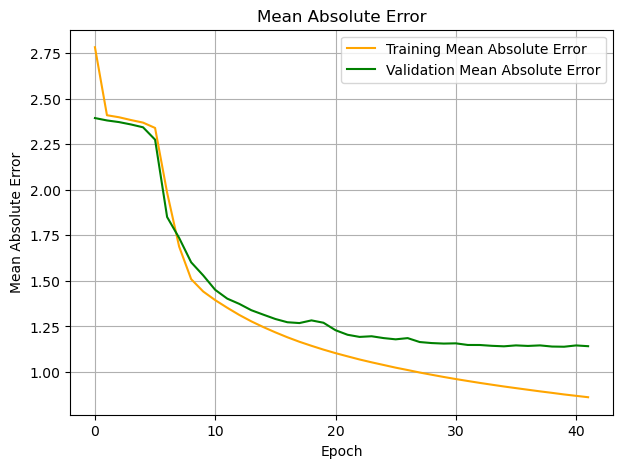

In [525]:
plt.figure(figsize=(7,5))
plt.plot(train_mae, color='orange', label='Training Mean Absolute Error')
plt.plot(val_mae, color='green', label='Validation Mean Absolute Error')
plt.title('Mean Absolute Error')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.grid(True)

### Model Evaluation

In [53]:
model = tf.keras.models.load_model('./saved_models/newpred_nn_v2_uk.keras')

In [55]:
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {test_mae:.4f}")


3229/3229 ━━━━━━━━━━━━━━━━━━━━ 2s 442us/step - loss: 2.4046 - mean_absolute_error: 1.1526
Test MAE: 1.1167


In [59]:
preds = model.predict(X_test)


3229/3229 ━━━━━━━━━━━━━━━━━━━━ 1s 434us/step


### Visualisation of results

In [ ]:
## creating a dataframe to store visualise outputs and plot against predictors
tempdf = pd.DataFrame({
    'y_test' : y_test,
    'latitude' : map_values['latitude'],
    'longitude' : map_values['longitude'],
    'altitude' : map_values['altitude'],
    'predicted' : preds.reshape(-1),
    'error' : y_test-preds.reshape(-1)
})
tempdf

In [63]:
tempdf_grouped = tempdf.groupby(['y_test'], as_index = False).agg({
    'predicted' : ['mean', 'std', 'median']
})
tempdf_grouped

y_test  predicted                     
                 mean       std     median
0     -5.8  -2.614633       NaN  -2.614633
1     -5.7  -2.776040       NaN  -2.776040
2     -5.4   0.579121       NaN   0.579121
3     -5.1  -2.402693  0.271299  -2.459128
4     -5.0  -2.782800       NaN  -2.782800
..     ...        ...       ...        ...
323   27.0  26.831446  0.000000  26.831446
324   27.1  24.279280  2.957870  24.279280
325   27.2  25.345339  0.000000  25.345339
326   27.6  26.774326  0.000000  26.774326
327   27.8  26.672256  0.000000  26.672256

[328 rows x 4 columns]

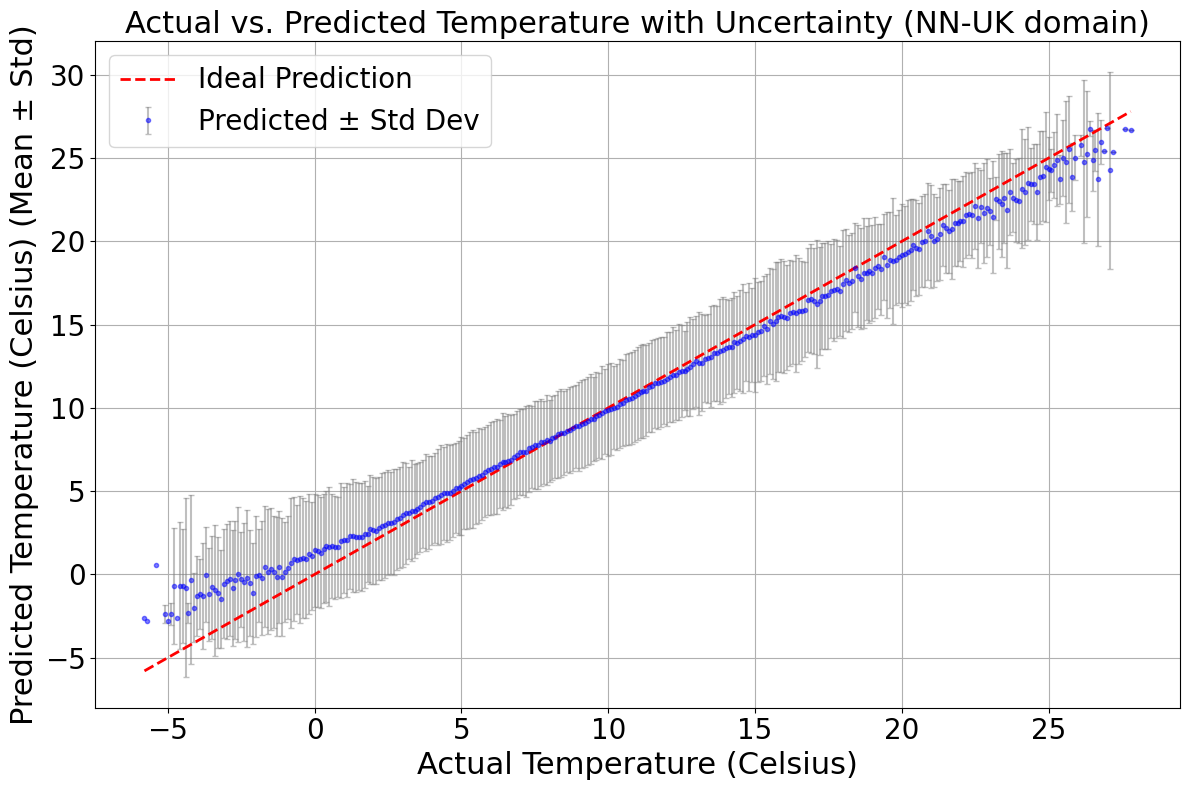

In [67]:
# Actual vs. Predicted Temperature with Uncertainty (NN-UK domain)

#errors = tempdf_grouped['predicted']['mean'] - tempdf_grouped['y_test'])
#errors = errors.astype(int)
plt.figure(figsize=(12, 8))
plt.errorbar(tempdf_grouped['y_test'], tempdf_grouped['predicted']['mean'], yerr=2*tempdf_grouped['predicted']['std'], fmt='o', alpha=0.5, markersize=3,
             ecolor='gray', capsize=2, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Ideal Prediction', linewidth=2)

plt.xlabel('Actual Temperature (Celsius)', fontsize=22)
plt.ylabel('Predicted Temperature (Celsius) (Mean ± Std)', fontsize=22)
plt.title('Actual vs. Predicted Temperature with Uncertainty (NN-UK domain)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


In [73]:
temp_bins = pd.cut(tempdf['y_test'], bins=234)
temp_bins

6030894      (4.108, 4.251]
6030895      (4.682, 4.826]
6030896      (4.682, 4.826]
6030897      (4.538, 4.682]
6030898      (4.538, 4.682]
                 ...       
8147103    (11.144, 11.287]
8147104    (12.436, 12.579]
8147105      (11.0, 11.144]
8147106    (10.426, 10.569]
8147107    (13.154, 13.297]
Name: y_test, Length: 103327, dtype: category
Categories (234, interval[float64, right]): [(-5.834, -5.656] < (-5.656, -5.513] < (-5.513, -5.369] < (-5.369, -5.226] ... (27.226, 27.369] < (27.369, 27.513] < (27.513, 27.656] < (27.656, 27.8]]

/var/folders/pw/b7xk2wbj2zlghgd_7c0zcfp40000gn/T/ipykernel_25539/155974274.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()


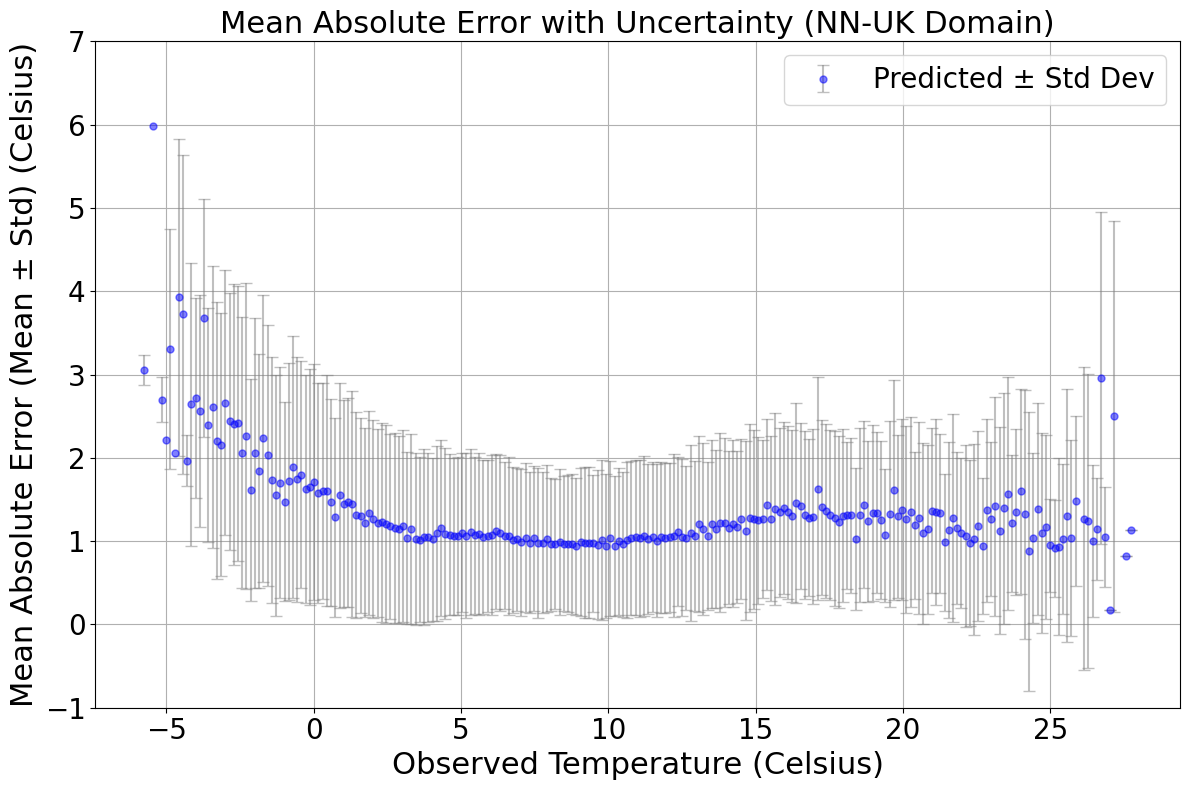

In [90]:
## Mean of MAE within temperature bins. the temperature range has been divided into 234 bins.
tempdf1 = tempdf.copy()
tempdf1['error'] = np.abs(tempdf1['error'])
temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()
temp_bin_error['temp_center'] = temp_bin_error['y_test'].apply(lambda x : x.mid)
temp_bin_error

plt.figure(figsize=(12, 8))
plt.errorbar(temp_bin_error['temp_center'], temp_bin_error['mean'], yerr=temp_bin_error['std'], fmt='o', alpha=0.5, markersize=5,
             ecolor='gray', capsize=4, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
#plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Perfect Prediction')

plt.ylim(-1,7)
#plt.ylim(-1,9)
plt.xlabel('Observed Temperature (Celsius)', fontsize=22)
plt.ylabel('Mean Absolute Error (Mean ± Std) (Celsius)', fontsize=22)
plt.title('Mean Absolute Error with Uncertainty (NN-UK Domain)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/pw/b7xk2wbj2zlghgd_7c0zcfp40000gn/T/ipykernel_25539/1332740787.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()


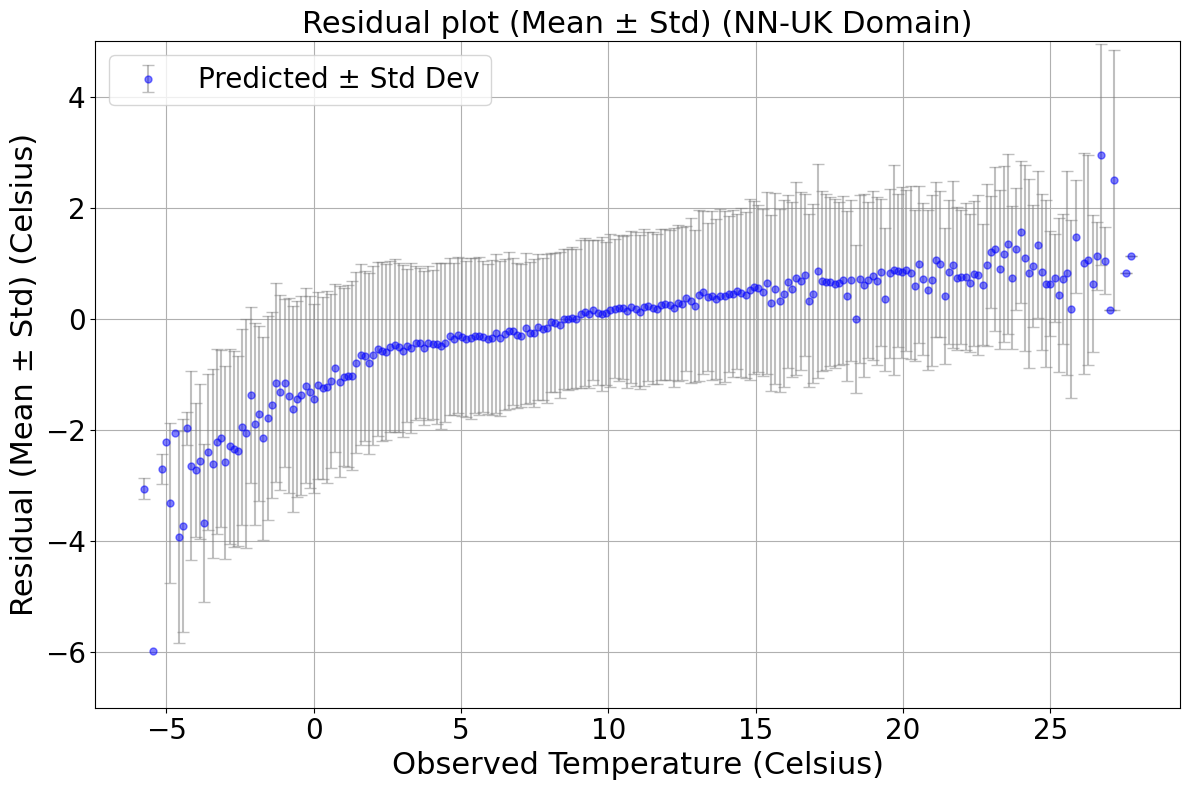

In [96]:
## Mean of residuals within temperature bins. the temperature range has been divided into 234 bins.
temp_bins = pd.cut(tempdf['y_test'], bins=234)
tempdf1 = tempdf.copy()
tempdf1['error'] = tempdf1['error']
temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()
temp_bin_error['temp_center'] = temp_bin_error['y_test'].apply(lambda x : x.mid)
temp_bin_error

plt.figure(figsize=(12, 8))
plt.errorbar(temp_bin_error['temp_center'], temp_bin_error['mean'], yerr=temp_bin_error['std'], fmt='o', alpha=0.5, markersize=5,
             ecolor='gray', capsize=4, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
#plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Perfect Prediction')

#plt.ylim(-2,19)
plt.ylim(-7,5)
plt.xlabel('Observed Temperature (Celsius)', fontsize=22)
plt.ylabel('Residual (Mean ± Std) (Celsius)', fontsize=22)
plt.title('Residual plot (Mean ± Std) (NN-UK Domain)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


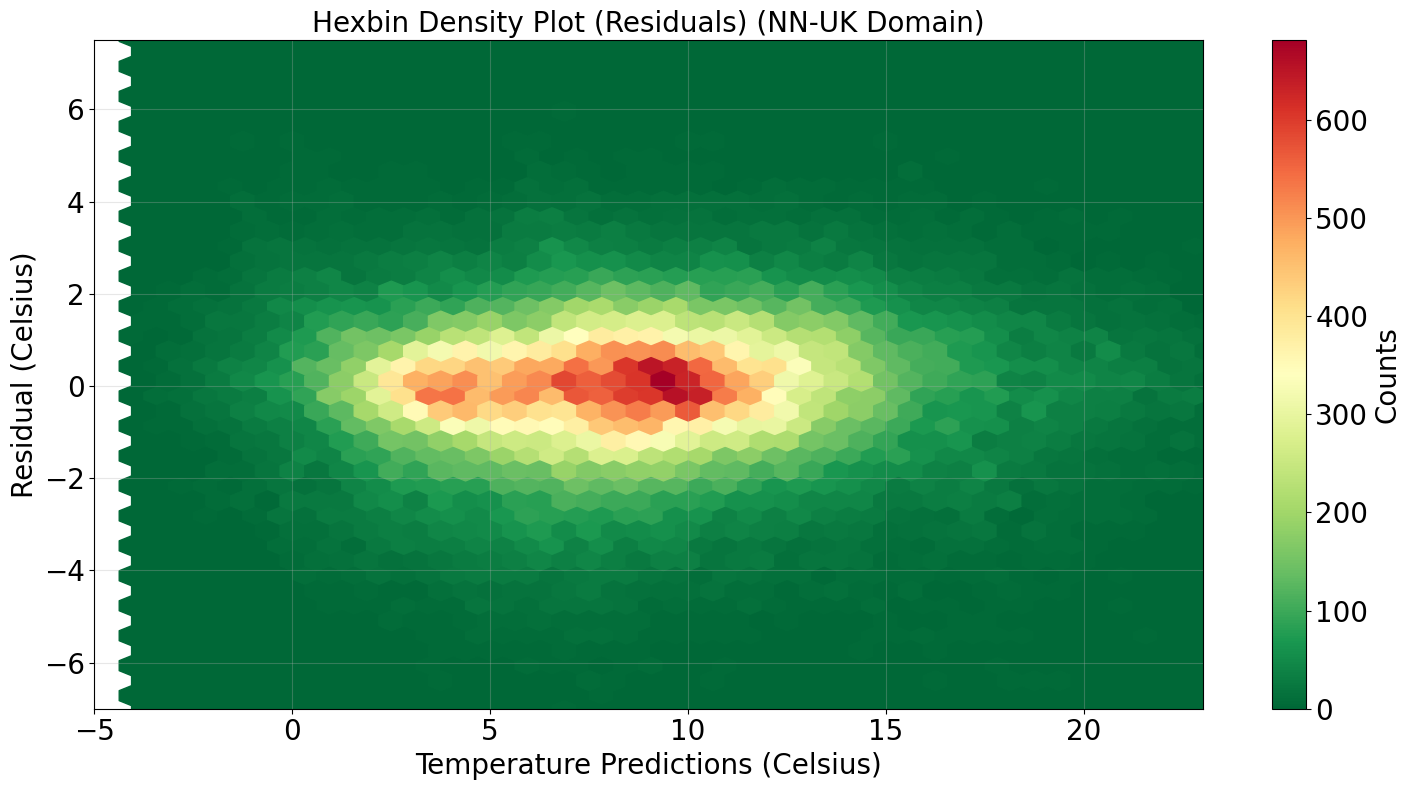

In [118]:
# Residual density plot

colors = ["green", "yellow", "red"]
custom_cmap = LinearSegmentedColormap.from_list("green_red", colors)

fig, ax = plt.subplots(figsize=(15, 8))

hb = ax.hexbin(
    tempdf['predicted'],
    tempdf['y_test'] - tempdf['predicted'],
    gridsize=50,
    cmap='RdYlGn_r'  
)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Counts', fontsize=20)   # colorbar label
cbar.ax.tick_params(labelsize=20)       # colorbar tick labels

ax.set_xlabel('Temperature Predictions (Celsius)', fontsize=20)
ax.set_ylabel('Residual (Celsius)', fontsize=20)
ax.set_title('Hexbin Density Plot (Residuals) (NN-UK Domain)', fontsize=20)

ax.set_ylim(-7, 7.5)
ax.set_xlim(-5, 23)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', which='both', labelsize=20)  

fig.tight_layout()
plt.show()


Text(0.5, 1.0, 'Actual vs Predicted Temperature (Test Set)')

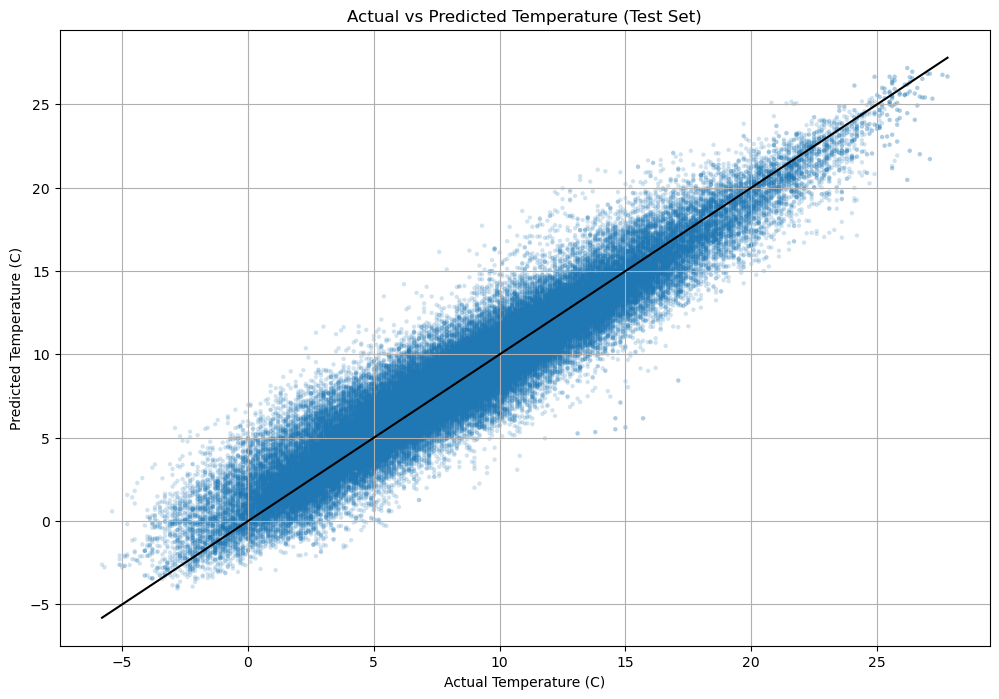

In [79]:
## Actual vs. Predicted Temperature

plt.figure(figsize=(12, 8))
plt.scatter(y_test, preds, s=10, alpha=0.2, edgecolors='none')
x_ = np.linspace(y_test.min(), y_test.max(), 100)
y_ = x_
plt.plot(x_, y_, color = 'black')
plt.grid(True)
#plt.xlim(-70,-35)
#plt.ylim(-80,-5)
plt.xlabel('Actual Temperature (C)')
plt.ylabel('Predicted Temperature (C)')
plt.title('Actual vs Predicted Temperature (Test Set)')

Text(0.5, 1.0, 'Residual Plot')

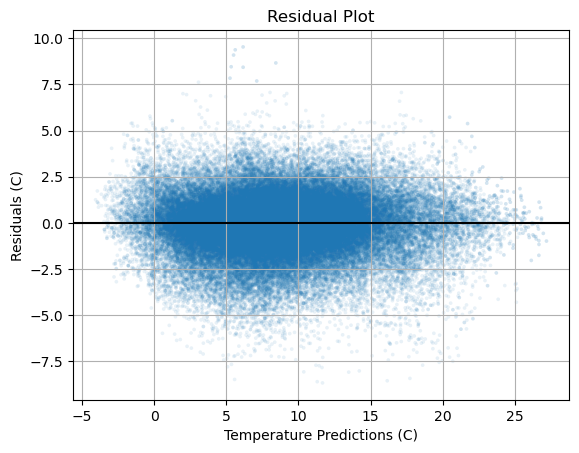

In [83]:
## Residual density plot
resids = tempdf['y_test'] - tempdf['predicted'] 
plt.scatter(tempdf['predicted'], resids, s=7, alpha=0.1, edgecolors='none')
plt.axhline(y=0, color='black')
plt.grid(True)
#plt.ylim((-20,40))
plt.xlabel('Temperature Predictions (C)')
plt.ylabel('Residuals (C)')
plt.title('Residual Plot')

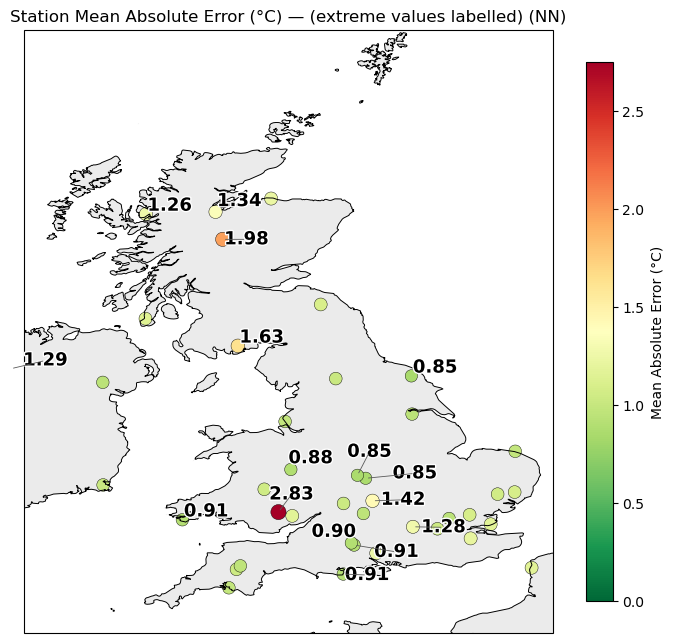

In [89]:
# MAE spatial distribution map

# df: columns ['station','lat','lon','mae']
fig = plt.figure(figsize=(7,8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-8, 2, 49.5, 60.9])
ax.add_feature(cfeature.LAND, facecolor='0.92'); ax.coastlines('10m', linewidth=0.7)

sizes = 30 + 90*np.sqrt(unique_test_locs['error']/unique_test_locs['error'].max())
sc = ax.scatter(unique_test_locs['longitude'], unique_test_locs['latitude'], c=unique_test_locs['error'], s=sizes, cmap='RdYlGn_r',
                edgecolor='k', linewidth=0.3, transform=ccrs.PlateCarree(), vmin=0, vmax=2.75)

# Label only extremes
idx = pd.concat([unique_test_locs.nlargest(8,'error'), unique_test_locs.nsmallest(8,'error')]).index.unique()
texts = []
for _, r in unique_test_locs.loc[idx].iterrows():
    t = ax.text(r['longitude'], r['latitude'], f"{r['error']:.2f}", transform=ccrs.PlateCarree(),
                fontsize=13, weight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    texts.append(t)

adjust_text(texts, expand_points=(1.2,1.6), force_points=0.5, force_text=0.5,
            arrowprops=dict(arrowstyle='-', color='0.35', lw=0.6))

cbar = plt.colorbar(sc, ax=ax, label="Mean Absolute Error (°C)", shrink=0.7)
ax.set_title("Station Mean Absolute Error (°C) — (extreme values labelled) (NN)")
plt.tight_layout()